# 5-Year Survival Classification
Build a 5-year survival label and train a baseline model.

## 1. Load Dataset and Inspect Schema
Load the processed CSV and review columns, data types, and missingness.

In [11]:
import sys
from pathlib import Path

# Ensure the repo root is on sys.path so `src` is importable
repo_root = Path.cwd().resolve().parent
sys.path.insert(0, str(repo_root))

import pandas as pd
from src.config import PROCESSED_DATA_DIR

data_path = PROCESSED_DATA_DIR / "breast_cancer_survival_processed.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Missing CSV at {data_path}")

df = pd.read_csv(data_path)
print("Shape:", df.shape)
display(df.head())

print("Column dtypes:")
display(df.dtypes)

print("Missing values (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))

Shape: (4023, 16)


,age,race,marital_status,t_stage,n_stage,sixth_stage,differentiation,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,regional_node_positive,survival_months,status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


Column dtypes:


age                       int64
race                        str
marital_status              str
t_stage                     str
n_stage                     str
sixth_stage                 str
differentiation             str
grade                     int64
a_stage                     str
tumor_size                int64
estrogen_status             str
progesterone_status         str
regional_node_examined    int64
regional_node_positive    int64
survival_months           int64
status                      str
dtype: object

Missing values (top 10):


age                0
race               0
marital_status     0
t_stage            0
n_stage            0
sixth_stage        0
differentiation    0
grade              0
a_stage            0
tumor_size         0
dtype: int64

## 2. Create 5-Year Survival Label
Define the label: 1 if survival_months >= 60, else 0. Validate class balance.

In [12]:
df["survived_5yr"] = (df["survival_months"] >= 60).astype(int)

print("5-year label balance:")
display(df["survived_5yr"].value_counts().rename("count"))
display(df["survived_5yr"].value_counts(normalize=True).rename("ratio"))

5-year label balance:


survived_5yr
1    2821
0    1202
Name: count, dtype: int64

survived_5yr
1    0.701218
0    0.298782
Name: ratio, dtype: float64

Overall 5-year label balance:


survived_5yr
0    1202
1    2821
Name: count, dtype: int64

survived_5yr
0    0.298782
1    0.701218
Name: ratio, dtype: float64

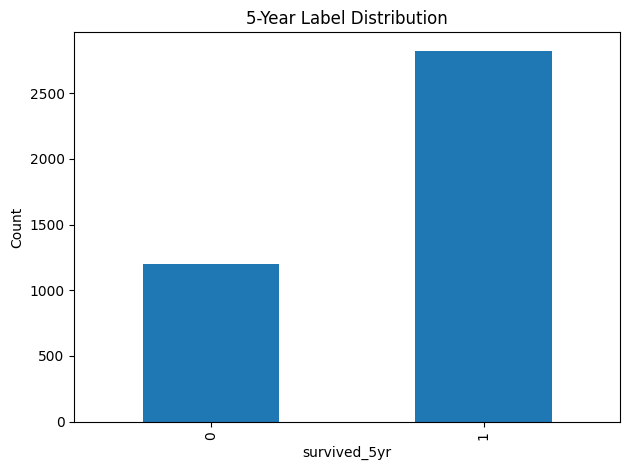

Train balance:


survived_5yr
0    0.298633
1    0.701367
Name: ratio, dtype: float64

Test balance:


survived_5yr
0    0.299379
1    0.700621
Name: ratio, dtype: float64

In [13]:
import matplotlib.pyplot as plt

print("Overall 5-year label balance:")
balance_counts = df["survived_5yr"].value_counts().sort_index()
balance_ratio = df["survived_5yr"].value_counts(normalize=True).sort_index()

display(balance_counts.rename("count"))
display(balance_ratio.rename("ratio"))

ax = balance_counts.plot(kind="bar", title="5-Year Label Distribution")
ax.set_xlabel("survived_5yr")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Train balance:")
display(y_train.value_counts(normalize=True).sort_index().rename("ratio"))
print("Test balance:")
display(y_test.value_counts(normalize=True).sort_index().rename("ratio"))

## 3. Encode Features and Prepare Train/Test Split
Select features, encode categoricals, scale numeric features, and split the data.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

target = "survived_5yr"
leakage_cols = ["survival_months", "status"]
feature_cols = [col for col in df.columns if col not in leakage_cols + [target]]

X = df[feature_cols]
y = df[target]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
 )

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (3218, 14) (3218,)
Test shape: (805, 14) (805,)


C:\Users\thanh\AppData\Local\Temp\ipykernel_19308\2610739691.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


## 4. Train Baseline Classifier
Train a baseline model on the 5-year label.

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 5. Evaluate 5-Year Classification Metrics
Compute standard metrics and do a simple threshold analysis.

In [16]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
 )

y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

print("Threshold analysis:")
for t in [0.3, 0.5, 0.7]:
    y_t = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_t)
    prec = precision_score(y_test, y_t, zero_division=0)
    rec = recall_score(y_test, y_t, zero_division=0)
    print(f"t={t:.1f} | precision={prec:.3f} recall={rec:.3f} | cm={cm.tolist()}")

Accuracy: 0.5664596273291925
Precision: 0.718052738336714
Recall: 0.6276595744680851
F1: 0.6698202459791863
ROC AUC: 0.5421485536034844
Confusion matrix:
 [[102 139]
 [210 354]]
              precision    recall  f1-score   support

           0      0.327     0.423     0.369       241
           1      0.718     0.628     0.670       564

    accuracy                          0.566       805
   macro avg      0.522     0.525     0.519       805
weighted avg      0.601     0.566     0.580       805

Threshold analysis:
t=0.3 | precision=0.705 recall=0.984 | cm=[[9, 232], [9, 555]]
t=0.5 | precision=0.718 recall=0.628 | cm=[[102, 139], [210, 354]]
t=0.7 | precision=0.000 recall=0.000 | cm=[[241, 0], [564, 0]]


## 6. Persist Model and Preprocessing Artifacts
Save the trained pipeline for reuse.

In [17]:
import json
from datetime import datetime
import joblib

from src.config import RESULTS_DIR

run_id = datetime.now().strftime("survival_5yr_%Y%m%d_%H%M%S")
run_dir = RESULTS_DIR / run_id
run_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(clf, run_dir / "survival_5yr_pipeline.joblib")

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, zero_division=0)),
    "f1": float(f1_score(y_test, y_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, y_proba)),
    "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
}
(run_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))

print("Saved artifacts to:", run_dir)

Saved artifacts to: E:\MIU\ML\Projects\ml-project\results\survival_5yr_20260605_213636
